# New Physics: Dark Photons and Photon Injection (PDE Solver)

Two scenarios that go beyond heat injection:

1. **Dark photon depletion** — $\gamma\to A'$ resonant conversion removes CMB photons
2. **Monochromatic photon injection** — line emission at fixed $x_{\rm inj}$ (e.g., $X\to\gamma\gamma$)

Both modify the photon spectrum directly; the PDE handles the subsequent DC/BR + Compton thermalization self-consistently.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spectroxide import (
    solve, mu_shape, y_shape, delta_n_to_delta_I, apply_style,
)
apply_style()


## 1. Dark photon oscillations

For mass $m_{A'}$ and kinetic mixing $\varepsilon$, resonant conversion at $\omega_{\rm pl}(z_{\rm res}) = m_{A'}$ depletes photons by $\Delta n(x) = -P(x)\,n_{\rm pl}(x)$. The Breit-Wigner is too narrow ($\Delta z/z \sim 10^{-14}$) for the PDE to resolve, so the solver uses NWA to set the IC at $z_{\rm res}$ and evolves the thermalization from there.


$m_{A'} = 3\times10^{-5}$ eV: mu=4.987e-04, y=1.684e-06, drho=-3.225e-04
$m_{A'} = 10^{-5}$ eV: mu=6.893e-04, y=2.390e-06, drho=-3.494e-04
$m_{A'} = 3\times10^{-6}$ eV: mu=7.259e-04, y=1.357e-06, drho=-3.578e-04


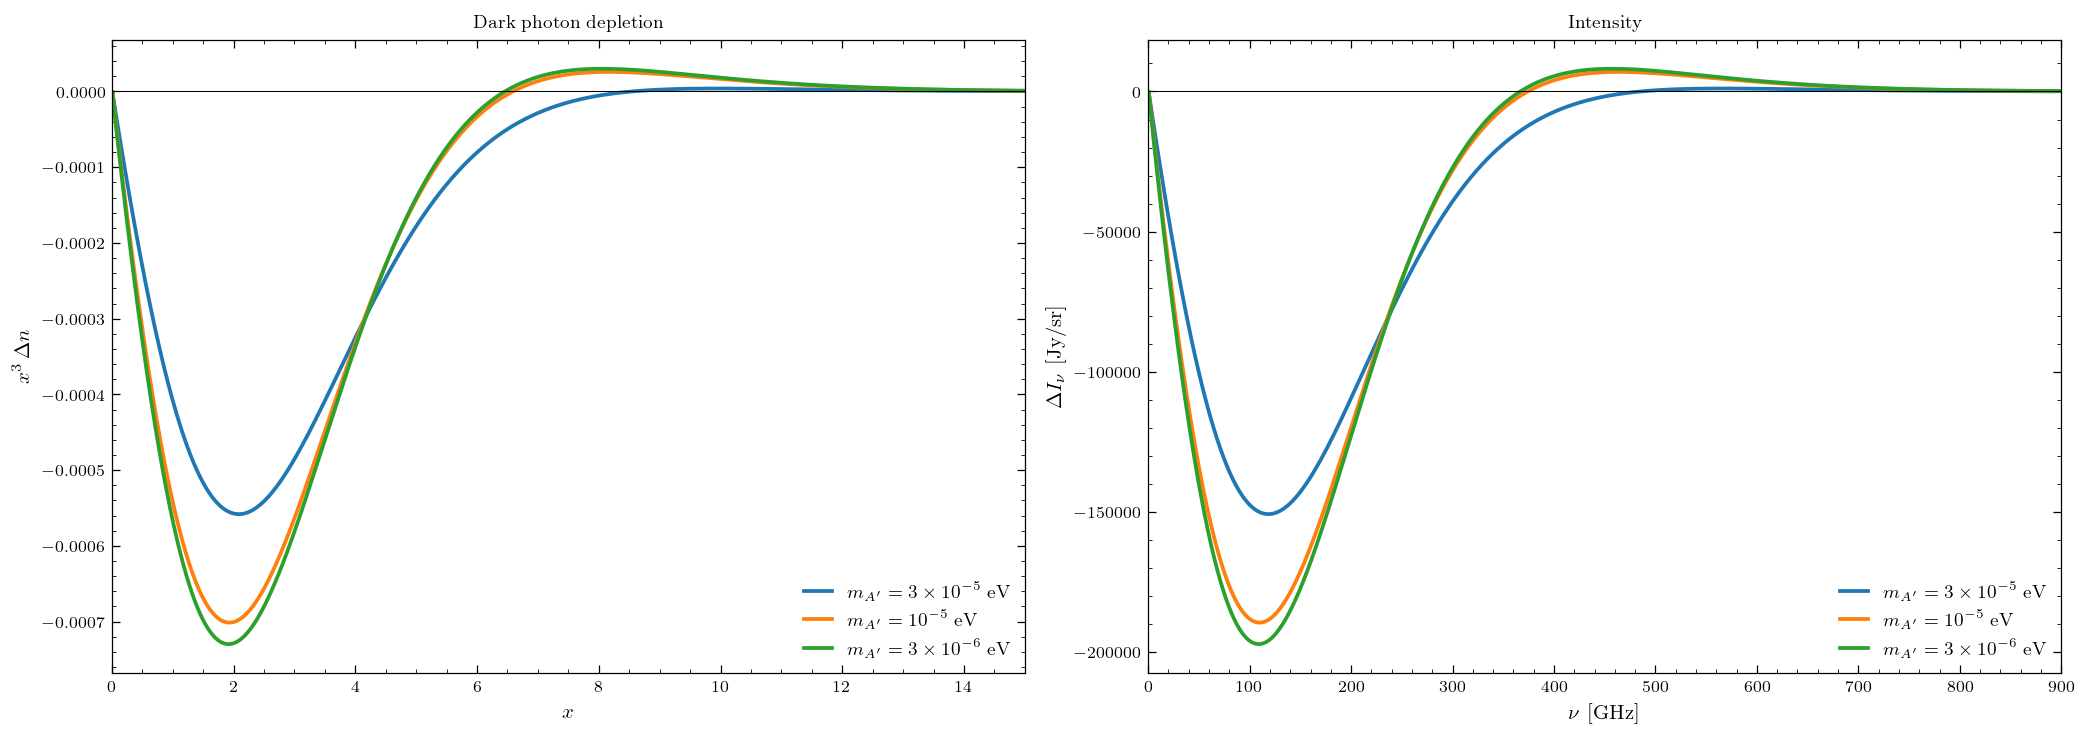

In [2]:
dp_configs = [
    {'epsilon': 1e-7, 'm_ev': 3e-5, 'label': r"$m_{A'} = 3\times10^{-5}$ eV"},
    {'epsilon': 1e-7, 'm_ev': 1e-5, 'label': r"$m_{A'} = 10^{-5}$ eV"},
    {'epsilon': 1e-7, 'm_ev': 3e-6, 'label': r"$m_{A'} = 3\times10^{-6}$ eV"},
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for cfg in dp_configs:
    r = solve(injection={'type': 'dark_photon_resonance', 'epsilon': cfg['epsilon'], 'm_ev': cfg['m_ev']},
              z_end=1e3)
    nu, dI = delta_n_to_delta_I(r.x, r.delta_n)
    ax1.plot(r.x, r.x**3 * r.delta_n, lw=1.8, label=cfg['label'])
    ax2.plot(nu, dI, lw=1.8, label=cfg['label'])
    print(f"{cfg['label']}: mu={r.mu:.3e}, y={r.y:.3e}, drho={r.delta_rho_over_rho:.3e}")

for ax in (ax1, ax2):
    ax.axhline(0, color='k', lw=0.5); ax.legend(fontsize=9)
ax1.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$', xlim=(0, 15), title='Dark photon depletion')
ax2.set(xlabel=r'$\nu$ [GHz]', ylabel=r'$\Delta I_\nu$ [Jy/sr]', xlim=(0, 900), title='Intensity')
plt.tight_layout(); plt.show()


## 2. Monochromatic photon injection

Photon injection at $x_{\rm inj}$ behaves qualitatively differently from heat:

- $x_i \ll 1$: rapidly absorbed by DC/BR → equivalent to heat injection
- $x_i \gg 1$: survives absorption, appears as a Compton-broadened bump
- $x_i \approx 3.6$: zero net $\mu$ (energy and number compensate)


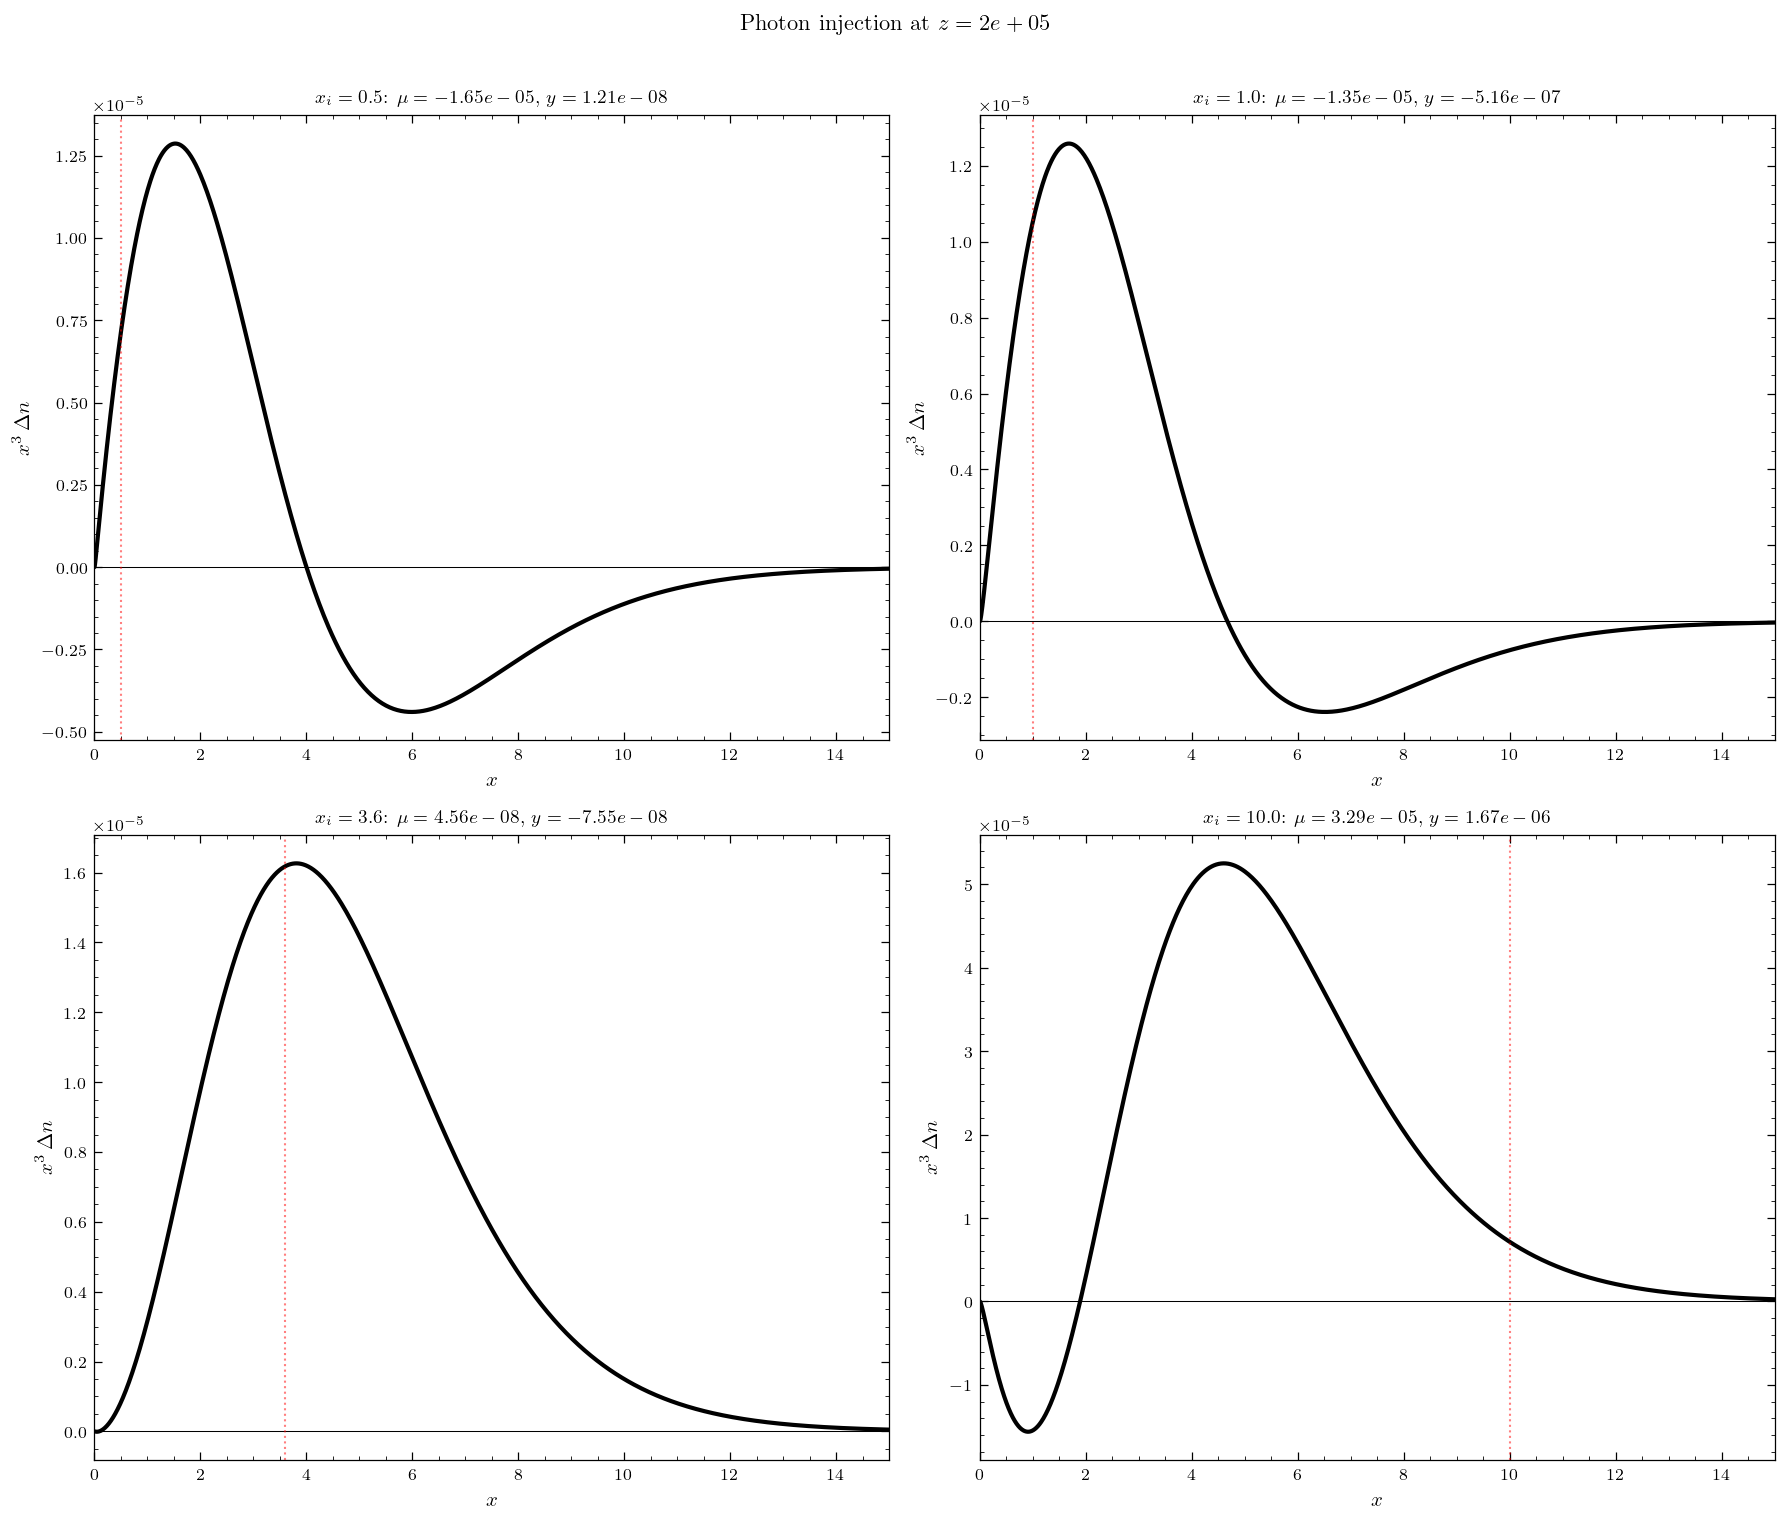

In [3]:
z_h = 2e5
x_inj_values = [0.5, 1.0, 3.6, 10.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, x_inj in zip(axes.flat, x_inj_values):
    sigma_z = max(z_h * 0.04, 100)
    r = solve(injection={'type': 'monochromatic_photon', 'x_inj': x_inj,
                         'delta_n_over_n': 1e-5, 'z_h': z_h, 'sigma_z': sigma_z},
              z_start=z_h + 7*sigma_z, z_end=1e3)
    ax.plot(r.x, r.x**3 * r.delta_n, 'k-', lw=2)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(x_inj, color='red', ls=':', lw=1, alpha=0.5)
    ax.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$', xlim=(0, 15),
           title=rf'$x_i={x_inj}$: $\mu={r.mu:.2e}$, $y={r.y:.2e}$')
plt.suptitle(rf'Photon injection at $z={z_h:.0e}$', y=1.01)
plt.tight_layout(); plt.show()

## 3. $\mu$ sign flip at $x_0 \approx 3.6$

$x_i < x_0$ → negative $\mu$ (extra cold photons); $x_i > x_0$ → positive $\mu$ (heating-like). The clean zero crossing at $x_0 \approx 3.6$ requires the deep $\mu$-era; in the $y$-era and transition the residual decomposes mostly onto $y$ and the $\mu$ zero shifts.

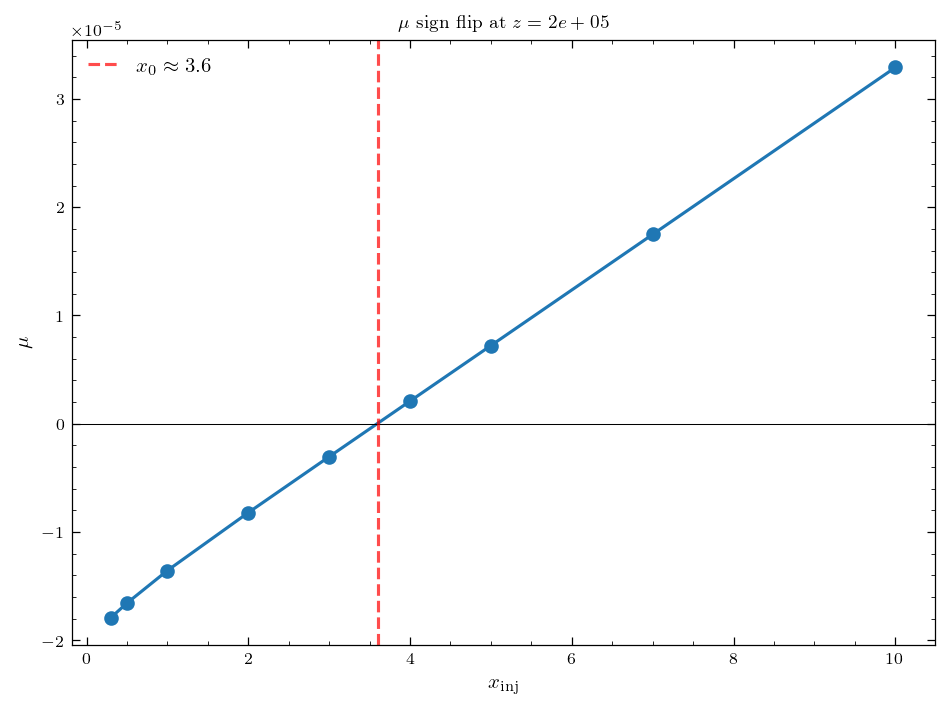

In [4]:
x_inj_scan = [0.3, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0]
mu_scan = []
for x_inj in x_inj_scan:
    sigma_z = max(z_h * 0.04, 100)
    r = solve(injection={'type': 'monochromatic_photon', 'x_inj': x_inj,
                         'delta_n_over_n': 1e-5, 'z_h': z_h, 'sigma_z': sigma_z},
              z_start=z_h + 7*sigma_z, z_end=1e3)
    mu_scan.append(r.mu)

fig, ax = plt.subplots()
ax.plot(x_inj_scan, mu_scan, 'o-', lw=1.5, ms=6)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(3.6, color='red', ls='--', lw=1.5, alpha=0.7, label=r'$x_0 \approx 3.6$')
ax.set(xlabel=r'$x_{\rm inj}$', ylabel=r'$\mu$',
       title=rf'$\mu$ sign flip at $z={z_h:.0e}$')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()


## Summary

| Scenario | injection dict / call |
|---|---|
| Dark photon | `{'type': 'dark_photon_resonance', 'epsilon': ..., 'm_ev': ...}` |
| Photon injection (PDE) | `{'type': 'monochromatic_photon', 'x_inj': ..., 'delta_n_over_n': ..., 'z_h': ...}` |
| Photon injection (GF) | `greens_function_photon(x, x_inj, z_h)`, `mu_from_photon_injection(...)` |

**Next:** `04_custom_scenarios.ipynb` (user-defined injection), `05_observational_constraints.ipynb` (FIRAS limits).
